In [11]:
import matplotlib.pyplot as plt
import hyperspy.api as hs
import numpy as np
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

def norm(data):
    for i,row in enumerate(data):
        for j,col in enumerate(row):
            data[i,j] = data[i,j]/data[i,j].max()
def non_negative(data):
    data -= data.min()

def interpol2d(S,x,y,d=2): 
    distances=[]
    values=[]
    for i in range(x - d, x + d + 1):
            for j in range(y - d, y + d + 1):
                # Calcular distancia euclidiana
                distance = np.sqrt((i - x) ** 2 + (j - y) ** 2)
                distances.append(distance)
                values.append(S.data[i, j])
    weights = np.array([1 / d if d > 0 else 0 for d in distances])  
    weights /= weights.sum()  # Normalizar los pesos

    # Valor interpolado
    S.data[x,y]= np.dot(weights, values)

def correct_drif(Data, inicio, pixeles_corridos, area):
    shape = Data.data.shape[:2]
    x0, y0 = inicio
    dx, dy = area

    if pixeles_corridos < 0:
        for j in range(y0+dy-pixeles_corridos, y0-dy, -1):
            for i in range(x0, x0+dx):
                Data.data[i, j] = Data.data[i, j+pixeles_corridos]
    else:
        for j in range(y0-dy, y0+dy+pixeles_corridos):
            for i in range(x0, x0+dx):
                Data.data[i, j] = Data.data[i, j+pixeles_corridos]

def save(nombre,componentes,datos):
    datos = np.array(datos)
    np.savetxt(nombre,datos.T,delimiter='\t', newline='\n', header='\t'.join(componentes),comments='')

In [9]:
s = hs.load('Data 1/4-STEM SI.dm4')
#s.spikes_removal_tool(interactive=True)

WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)
WARNING | Hyperspy | `signal_type='EELS'` not understood. See `hs.print_known_signal_types()` for a list of installed signal types or https://github.com/hyperspy/hyperspy-extensions-list for the list of all hyperspy extensions providing signals. (hyperspy.io:745)


In [7]:
s

[<Signal2D, title: ADF Image (SI Survey), dimensions: (|512, 512)>,
 <Signal2D, title: ADF Image, dimensions: (|422, 321)>,
 <Signal1D, title: EELS Spectrum Image, dimensions: (422, 321|1638)>]

In [16]:
a=s[2]

In [23]:
a.metadata

├── Acquisition_instrument
│   └── TEM
│       ├── Detector
│       │   └── EELS
│       │       ├── aperture_size = 1.0
│       │       ├── collection_angle = 7.58
│       │       ├── dwell_time = 0.0005
│       │       ├── frame_number = 1
│       │       └── spectrometer = GIF Continuum K3 HR
│       ├── Stage
│       │   ├── tilt_alpha = 0.00878401595715065
│       │   ├── tilt_beta = 0.0
│       │   ├── x = 0.08087659999999999
│       │   ├── y = -0.055130000000000005
│       │   └── z = -0.255033
│       ├── acquisition_mode = STEM
│       ├── beam_current = 0.0
│       ├── beam_energy = 300.0
│       ├── camera_length = 29.5
│       ├── convergence_angle = 21.22927922811815
│       └── magnification = 320000.0
├── General
│   ├── FileIO
│   │   └── 0
│   │       ├── hyperspy_version = 2.3.0
│   │       ├── io_plugin = rsciio.digitalmicrograph
│   │       ├── operation = load
│   │       └── timestamp = 2025-11-12T16:45:24.211098+01:00
│   ├── date = 2025-10-07
│   ├── original_filename = 4-STEM SI.dm4
│   ├── time = 01:47:37
│   └── title = EELS Spectrum Image
└── Signal
    ├── Noise_properties
    │   └── Variance_linear_model
    │       ├── gain_factor = 1.0
    │       └── gain_offset = 0.0
    ├── quantity = Intensity (Counts)
    └── signal_type = EELS

In [ ]:
#correct_drif(s,[342,218],-17,[50,50])
#correct_drif(s,[341,311],-17,[5,10])
#correct_drif(s,[138,172],14,[140,222])
correct_drif(s,[169,147],5,[40,170])

s.plot()

In [ ]:
s.align_zero_loss_peak()
s.plot()

In [ ]:
sc = s.isig[.5:3.5]
sc.crop(0,0,s.data.shape[:2][1]-34)
#sc.crop(1,0,s.data.shape[:2][0]-95)

#norm(sc.data)
sc.plot()

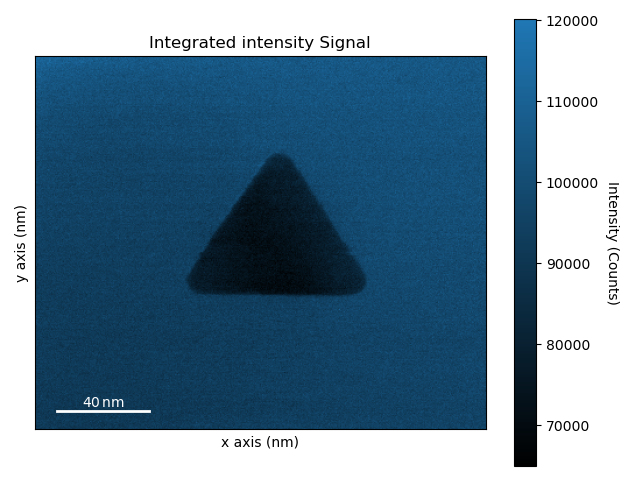

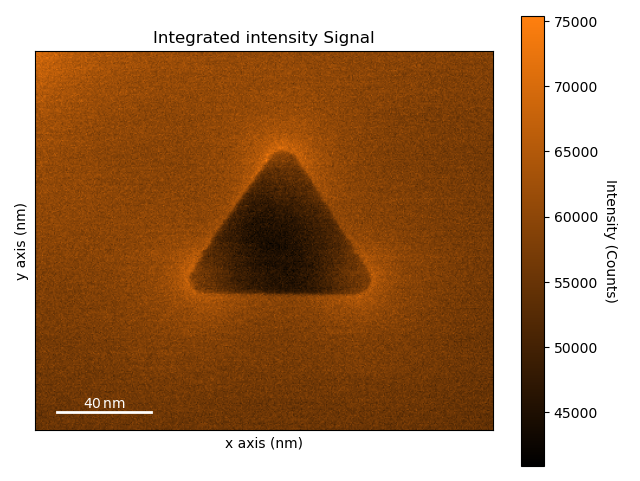

([SpanROI(left=0.5, right=1.2475), SpanROI(left=1.2475, right=1.995)],
 [<Signal2D, title: Integrated intensity, dimensions: (|388, 321)>,
  <Signal2D, title: Integrated intensity, dimensions: (|388, 321)>])

In [ ]:
sc.plot()
hs.plot.plot_roi_map(sc, rois=2)

In [ ]:
sc.decomposition("sklearn_pca") 
#sc.decomposition(True) 
sc.learning_results.summary()
sc.plot_explained_variance_ratio(n=40)
a = sc.estimate_elbow_position(explained_variance_ratio=None, log=True, max_points=40)
print(f'Componentes principales: {a}')

In [ ]:
sc.plot_decomposition_results()

In [ ]:
sc.blind_source_separation(4, diff_order=1)
_ = sc.plot_bss_loadings()
_ = sc.plot_bss_factors()

In [ ]:
sm=sc.get_decomposition_model(2*a)

In [ ]:
sm.decomposition(True, algorithm="NMF", output_dimension=2*a,max_iter=50000)
#sm.plot_decomposition_results()

In [ ]:
sm.learning_results.summary()
_ = sm.plot_decomposition_loadings()
_ = sm.plot_decomposition_factors()

In [ ]:
sm.T.plot()

In [ ]:
A = sm.get_decomposition_loadings()

B =sm.get_decomposition_factors().as_signal1D(1)

In [ ]:
#save('Site5_triang_profile_componentes_.txt',["Energy(eV)", "Componente 1","Componente 2","Componente 3","Componente 4"],[B.axes_manager[1].axis,B.data[0,:], B.data[1,:], B.data[2,:], B.data[3,:]])
save('Site2_triang_profile_componentes_.txt',["Energy(eV)", "Componente 1","Componente 2","Componente 3"],[B.axes_manager[1].axis,B.data[0,:], B.data[1,:], B.data[2,:]])
#save('Site4_triang_profile_componentes_.txt',["Energy(eV)", "Componente 1","Componente 2","Componente 3","Componente 4","Componente 5"],[B.axes_manager[1].axis,B.data[0,:], B.data[1,:], B.data[2,:], B.data[3,:], B.data[4,:]])


In [ ]:
#guardar imágenes de las componentes
colores = ['Grays','Reds','Blues','Greens','Purples','YlOrBr']
for i in range(3):
    _ = sm.plot_decomposition_loadings([i],cmap=colores[i],title='')
    plt.savefig(f"Site2_triang_Componente_{i}_.png",dpi=600)

In [ ]:
save('Site4_Triangulos_profile_componentes_bin.txt',["Energy(eV)", "Componente 1","Componente 2","Componente 3"],[B.rebin(scale=[2,1]).axes_manager[1].axis,B.rebin(scale=[2,1]).data[0,:], B.rebin(scale=[2,1]).data[1,:], B.rebin(scale=[2,1]).data[2,:]])



In [ ]:
colores = ['Grays','Reds','Blues','Greens','Purples','YlOrBr']
for i in range(3):
    fig, ax = plt.subplots()
    p = ax.imshow(A.rebin(scale=[2,1,1]).data[i],cmap=colores[i], interpolation='nearest', extent=A.rebin(scale=[2,1,1]).axes_manager.signal_extent)
    fontprops = fm.FontProperties(size=15)
    scalebar = AnchoredSizeBar(
            transform=ax.transData, size=10, label='10 nm',
            loc=4, frameon=False,
            color='white', size_vertical=0.9,
            label_top=False,
            fontproperties=fontprops)
    ax.add_artist(scalebar)
    ax.set_axis_off()
    fig.colorbar(p,ax=ax)
    plt.savefig(f"Site4_Triangulos_Componente_{i}_bin.png",dpi=600)


# 